In [29]:
# load in libraries
import pandas as pd 
import sqlite3
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [7]:
# make the database connection 
conn = sqlite3.connect('../Data/bookstore.db')

### Query 1: List the title, genre, and full author name for every book sold at a store in the Pacific region. Show each sale as its own row 

In [21]:
query1 = """select  books.title as Title, genres.name as Genre, authors.first_name || ' ' || authors.last_name AS Author_Name
from transactions
join books on transactions.book_id = books.book_id
join genres on books.genre_id = genres.genre_id
join authors on books.author_id = authors.author_id
join stores on transactions.store_id = stores.store_id
where stores.store_region = 'Pacific'
"""

In [23]:
# execute the query
result1 = pd.read_sql(query1, conn)
result1

,Title,Genre,Author_Name
0,The Quiet Hours,Fiction,Ocean Vuong
1,The Quiet Hours,Fiction,Ocean Vuong
2,The Quiet Hours,Fiction,Ocean Vuong
3,The Quiet Hours Vol. 2,Fiction,Malcolm Gladwell
4,The Quiet Hours Vol. 2,Fiction,Malcolm Gladwell
...,...,...,...
1754,The Habit Code Vol. 2,Self-Help,Toni Morrison
1755,The Habit Code Vol. 2,Self-Help,Toni Morrison
1756,The Habit Code Vol. 2,Self-Help,Toni Morrison
1757,The Habit Code Vol. 2,Self-Help,Toni Morrison


In [24]:
# create a visualization
genre_counts = result1['Genre'].value_counts()
genre_counts

Genre
Fantasy            292
Fiction            284
Science Fiction    283
History            278
Mystery            270
Biography          266
Self-Help           86
Name: count, dtype: int64

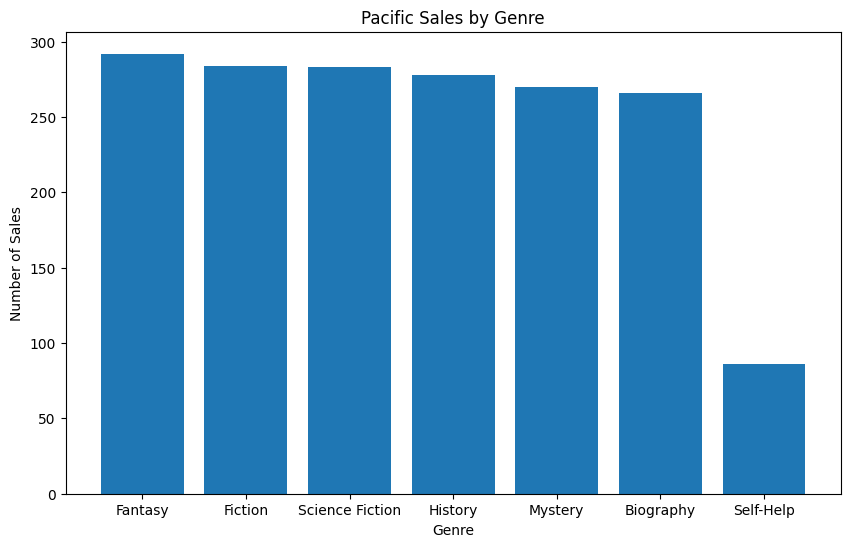

In [ ]:
plt.figure(figsize=(10,6))
plt.bar(genre_counts.index, genre_counts.values)

plt.xlabel('Genre')
plt.ylabel('Number of Sales')
plt.title('Pacific Sales by Genre')

plt.show()

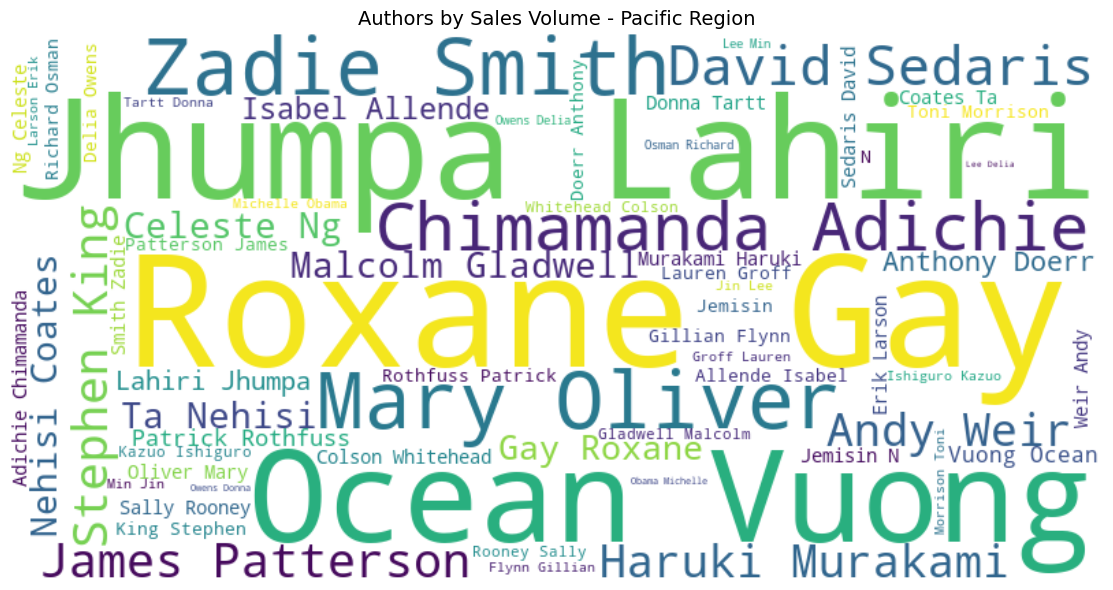

In [30]:
text = ' '.join(result1['Author_Name'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Authors by Sales Volume - Pacific Region', fontsize=14)
plt.tight_layout()
plt.show()

Discuss

### Query 2: Which genre generated the most total revenue across all transactions? Return the top 5 genres ranked by total sales, highest to lowest

In [ ]:
query2 = """ """

In [ ]:
# execute the query

In [ ]:
# create a visualization

Discuss

### Query 3: Find every member who has spent more than $200 in total across all their purchases. Return their full name, membership tier, and their total spend — but only include members who have made at least 3 separate transactions.

In [ ]:
query3 = """ """

In [ ]:
# execute the query

In [ ]:
# create a visualization

Discuss

### Query 4: For each publisher, find the single book (by title) that has generated the most total revenue. Return the publisher name, book title, and that book's total revenue.

In [ ]:
query4 = """ """

In [ ]:
# execute the query

In [ ]:
# create a visualization

Discuss

In [ ]:
conn.close()